# CAFE5 analysis & report


In [51]:
import os
import re
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dendropy
from pathlib import Path
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable
from cmcrameri import cm

CAFE="/hpcfs/users/a1864358/sanders_lab/phylogenomics/cafe"; os.chdir(CAFE)
mc=pd.read_csv("analysis/model_comparison.tsv",sep="\t")

REPORTED_MODEL="Gamma k4+error"
BESTDIR="runs/"+mc.set_index("name").loc[REPORTED_MODEL,"dir"]
PREFIX="Gamma" if os.path.exists(BESTDIR+"/Gamma_results.txt") else "Base"  # Base or Gamma

treeFile = Path("/hpcfs/users/a1864358/sanders_lab/phylogenomics/cafe/trees/species_tree_ultrametric.nwk")
    # species tree with 1 calibration (`02_dating.ipynb`)
multicalTree = Path("/hpcfs/users/a1864358/sanders_lab/phylogenomics/cafe/trees/species_tree_ultrametric_multical.nwk")
    # species tree with 5 calibrations (`03_multicalibration_dating.ipynb`)
    

ann=pd.read_csv("inputs/og_annotation.tsv",sep="\t").set_index("FamilyID")
smap=pd.read_csv("inputs/species_map.tsv",sep="\t").set_index("code")["species"].to_dict()
def fn(og): return ann.consensus_product.get(og,"?")

#### Node --> clade map (from the ancestral-reconstruction tree)
Parse CAFE's nodes --> so each branch maps to a named **clade**.
- use cafe <model>_change.tab [= record of how many genes each family gained or lost on each branch]

In [52]:
# load tree (ancestral-reconstruction)
asr=open(glob.glob(BESTDIR+"/*_asr.tre")[0]).read()
line=[l for l in asr.splitlines() if l.strip().startswith("TREE")][0]


# Strip CAFE decorations so dendropy gets plain Newick: drop '*' marks and
    # '_count' suffixes, keep tip names, and turn internal <id> labels into integers
s=line.split("=",1)[1].strip().rstrip(";")
s=line.split("=",1)[1].strip().rstrip(";")
s=s.replace("*","")
s=re.sub(r"_\d+","",s)                     # drop _count
s=re.sub(r"([A-Za-z][A-Za-z0-9]*)<\d+>", r"\1", s)  # tip NAME<id> -> NAME
s=re.sub(r"<(\d+)>", r"\1", s)             # internal <id> -> integer label

# Parse rooted tree
t=dendropy.Tree.get(data=s+";",schema="newick",rooting="force-rooted")
node_tips={}

for nd in t.postorder_node_iter(): # map each internal node id to the tips below it
    tips = frozenset(l.taxon.label for l in nd.leaf_iter())
    lab = nd.label if not nd.is_leaf() else None
    if lab: node_tips[int(lab)] = tips

# Column names in the change table use the same node ids as the tree
hdr=pd.read_csv(glob.glob(BESTDIR+"/*_change.tab")[0],sep="\t",nrows=0).columns[1:]

# Split "hcure<3>" or "<18>" into (species code or None, node id)
def parse_col(c):
    m=re.match(r"([A-Za-z]+)?<(\d+)>",c); return (m.group(1),int(m.group(2)))
colmap={c:parse_col(c) for c in hdr}

MARINE={"hcy","hcure","hcurw","horn","hmaj"}

# Name an internal node from its descendant tip set. None means leave it as anc(...).
def clade_name(nid, tips):
    names={"hcure","hcurw"};
    if tips=={"hcure","hcurw"}: return "H. curtus E/W"
    if tips=={"hmaj","horn"}: return "H. major+ornatus"
    if tips==MARINE: return "SEA-SNAKE ancestor (Hydrophis crown)"
    if tips=={"nscut","ptext"}: return "terrestrial elapids"
    if tips=={"nhel","tele"}: return "colubrids"
    if tips==MARINE|{"nscut","ptext"}: return "Elapidae ancestor"
    if tips=={"vberus"}: return "viperid" 
    if tips=={"caspera"}: return "boidae"
    return None

# One row per change-table column. Tips get a species name; internal nodes get a clade name or the raw tip list
rows=[]
for c,(nm,nid) in colmap.items():
    if nm:  # tip
        rows.append((c,nid,smap.get(nm,nm),"tip",nm in MARINE))
    else:
        tips=node_tips.get(nid,frozenset())
        rows.append((c,nid,clade_name(nid,tips) or "anc("+",".join(sorted(tips))+")","internal",tips<=MARINE and len(tips)>0))

nodes=pd.DataFrame(rows,columns=["col","id","clade","kind","marine"]).set_index("col")
nodes

,id,clade,kind,marine
col,,,,
vkomodo<1>,1,Varanus komodoensis,tip,False
caspera<2>,2,Candoia aspera,tip,False
hcure<3>,3,Hydrophis curtus (E),tip,True
hcurw<4>,4,Hydrophis curtus (W),tip,True
hmaj<5>,5,Hydrophis major,tip,True
horn<6>,6,Hydrophis ornatus,tip,True
hcy<7>,7,Hydrophis cyanocinctus,tip,True
nscut<8>,8,Notechis scutatus,tip,False
ptext<9>,9,Pseudonaja textilis,tip,False


### Rapidly evolving gene families (genome-wide)
Families whose overall size change is significant under the birth–death model (family-wide p<0.05).

In [53]:
fr=pd.read_csv(glob.glob(BESTDIR+"/*_family_results.txt")[0],sep="\t")

fr.columns=[c.lstrip("#") for c in fr.columns]

pcol=[c for c in fr.columns if "pvalue" in c.lower()][0]

sig=fr[fr[pcol]<0.05].copy(); sig["function"]=sig["FamilyID"].map(fn)

print(f"Rapidly evolving families: {len(sig)} / {len(fr)}  ({100*len(sig)/len(fr):.1f}%)")
# top functional categories among rapid families

sig["gene"]=sig["function"].str.split(":").str[0]

top=sig["gene"].value_counts().head(15)

print("\nTop gene classes among rapidly evolving families:"); print(top.to_string())

Rapidly evolving families: 1691 / 16341  (10.3%)

Top gene classes among rapidly evolving families:
gene
Olfactory receptor (OR)                119
Zinc finger (KRAB/C2H2)                 36
Vomeronasal type-2 receptor (V2R)       28
Immune (Ig / MHC)                       18
Transposable element / retroelement     16
Cytochrome P450                         16
C-type lectin                            5
CFH                                      4
PINLYP                                   4
SAT2                                     3
USP46                                    3
HIST2H2BF                                3
MRC1                                     3
REG4                                     3
ADAM29                                   3


In [54]:
# genes in those families (counts) + positions
# types of TEs + position

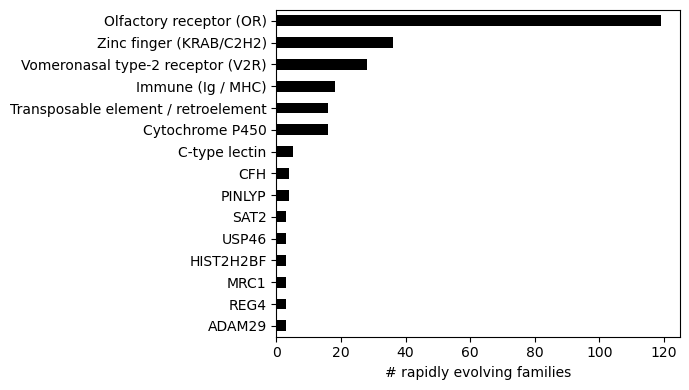

In [55]:
fig,ax=plt.subplots(figsize=(7,4))
top[::-1].plot.barh(ax=ax,color="black")
ax.set(xlabel="# rapidly evolving families")
ax.set(ylabel="")
plt.tight_layout(); plt.savefig("figures/nb3_rapid_classes.png",dpi=130); plt.show()

### Branch-wise expansions vs contractions
From `change.tab`: per branch, total genes gained (Σ positive) and lost (Σ negative) summed over all families, and the count of families with a **significant** shift on that branch (`branch_probabilities` p<0.05).

In [56]:
ch=pd.read_csv(glob.glob(BESTDIR+"/*_change.tab")[0],sep="\t").set_index("FamilyID")

bp=pd.read_csv(glob.glob(BESTDIR+"/*_branch_probabilities.tab")[0],sep="\t").set_index("FamilyID")

gain=ch.clip(lower=0).sum(); loss=(-ch.clip(upper=0)).sum()

# branch_probabilities: N/A for non-informative; significant if 0<p<0.05

bpn=bp.apply(pd.to_numeric,errors="coerce")

rapid_br=(bpn<0.05).sum()

summ=nodes.join(pd.DataFrame({"genes_gained":gain,"genes_lost":loss,"rapid_families":rapid_br}))
summ["net"]=summ["genes_gained"]-summ["genes_lost"]
summ=summ.sort_values("rapid_families",ascending=False)
summ[["clade","kind","marine","genes_gained","genes_lost","net","rapid_families"]]

,clade,kind,marine,genes_gained,genes_lost,net,rapid_families
col,,,,,,,
tele<11>,Thamnophis elegans,tip,False,1062,681,381,605
nhel<10>,Natrix helvetica,tip,False,775,368,407,486
nscut<8>,Notechis scutatus,tip,False,199,1144,-945,478
vberus<12>,Vipera berus,tip,False,1165,711,454,347
hcurw<4>,Hydrophis curtus (W),tip,True,306,287,19,341
<22>,terrestrial elapids,internal,False,25,410,-385,314
ptext<9>,Pseudonaja textilis,tip,False,147,554,-407,314
<18>,SEA-SNAKE ancestor (Hydrophis crown),internal,True,286,403,-117,308
hmaj<5>,Hydrophis major,tip,True,230,172,58,277


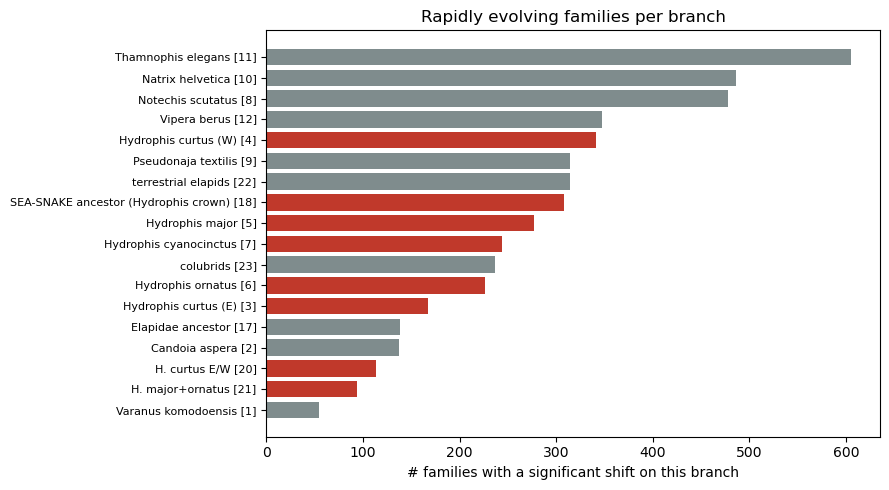

In [57]:
fig, ax = plt.subplots(figsize=(9, 5))

drop = {"<13>", "<14>", "<15>", "<16>", "<19>"}
d = summ.loc[~summ.index.isin(drop)].sort_values("rapid_families")
y = np.arange(len(d))
cols = ["#c0392b" if m else "#7f8c8d" for m in d["marine"]]

ax.barh(y, d["rapid_families"], color=cols)
ax.set_yticks(y)
ax.set_yticklabels([f"{c} [{i}]" for c, i in zip(d["clade"], d["id"])], fontsize=8)
ax.set(
    xlabel="# families with a significant shift on this branch",
    title="Rapidly evolving families per branch",
)

plt.tight_layout()
plt.savefig("figures/nb3_branch_rapid.png", dpi=130)
plt.show()

#### The sea-snake radiation 
- node `<18>` (Hydrophis crown ancestor)
- Gene families that expanded or contracted **significantly on the branch leading to sea snakes**, with functions.

In [58]:
def sig_on_branch(col, direction=None):
    fams=bpn.index[bpn[col]<0.05]              # families significant on THIS branch (label-aligned)
    c=ch.loc[fams,col]; p=bpn.loc[fams,col]
    out=pd.DataFrame({"FamilyID":list(fams),"change":c.values,"pval":p.values})
    if direction=="exp": out=out[out.change>0]
    if direction=="con": out=out[out.change<0]
    out["function"]=out["FamilyID"].map(fn); return out.sort_values("change",key=abs,ascending=False)
    

MAR="<18>"  # column name check
marcol=[c for c in ch.columns if c.strip()=="<18>"][0]

exp=sig_on_branch(marcol,"exp"); con=sig_on_branch(marcol,"con")


print(f"Sea-snake ancestor (node <18>): {len(exp)} significant expansions, {len(con)} significant contractions")
print("\n Top EXPANSIONS on the sea-snake ancestor \n")
print(exp.head(20).to_string(index=False))
print("\nTop CONTRACTIONS on the sea-snake ancestor \n")
print(con.head(15).to_string(index=False))

Sea-snake ancestor (node <18>): 105 significant expansions, 203 significant contractions

 Top EXPANSIONS on the sea-snake ancestor 

 FamilyID  change         pval                            function
OG0000021      20 8.756430e-40 Transposable element / retroelement
OG0000015      20 7.109680e-38 Class C GPCR / V2R-like (uncurated)
OG0000035      15 4.425840e-31 Transposable element / retroelement
OG0000005      15 2.562280e-21             Zinc finger (KRAB/C2H2)
OG0000018      12 2.560060e-21             Zinc finger (KRAB/C2H2)
OG0000007      11 9.866910e-17   Vomeronasal type-2 receptor (V2R)
OG0000070       9 4.646960e-19 Transposable element / retroelement
OG0000008       9 4.348090e-13 Transposable element / retroelement
OG0000038       7 5.379270e-13                               COX11
OG0000094       7 4.723090e-15 Transposable element / retroelement
OG0000114       6 4.761620e-13                             FAM188B
OG0000073       5 4.800470e-11                               S

In [59]:
exp.to_csv("analysis/seasnake_ancestor_expansions.tsv",sep="\t",index=False)
con.to_csv("analysis/seasnake_ancestor_contractions.tsv",sep="\t",index=False)
sig[["FamilyID",pcol,"function"]].to_csv("analysis/rapidly_evolving_families.tsv",sep="\t",index=False)
summ.reset_index().to_csv("analysis/branch_summary.tsv",sep="\t",index=False)
print("saved analysis/: seasnake_ancestor_expansions/contractions, rapidly_evolving_families, branch_summary")

saved analysis/: seasnake_ancestor_expansions/contractions, rapidly_evolving_families, branch_summary


###  Marine-lineage focus: families expanded across ALL sea snakes
Families with net gain on the sea-snake ancestor **and** high copy number retained in extant *Hydrophis* — candidate marine-adaptation gene families.

In [60]:
cnt=pd.read_csv(glob.glob(BESTDIR+"/*_count.tab")[0],sep="\t").set_index("FamilyID")


tipcols={sp:[c for c in cnt.columns if re.match(rf"{sp}<",c)][0] for sp in ["hcy","hcure","hcurw","horn","hmaj","nscut","ptext"]}

marine_mean=cnt[[tipcols[s] for s in ["hcy","hcure","hcurw","horn","hmaj"]]].mean(axis=1)
terr_mean  =cnt[[tipcols[s] for s in ["nscut","ptext"]]].mean(axis=1)

cand=pd.DataFrame({"marine_mean":marine_mean,"terr_elapid_mean":terr_mean})
cand["diff"]=cand["marine_mean"]-cand["terr_elapid_mean"]
cand["function"]=cand.index.map(fn)
cand=cand[cand.index.isin(exp["FamilyID"])].sort_values("diff",ascending=False)


print("Sea-snake-expanded families (higher in marine Hydrophis than terrestrial elapids):")
print(cand.head(30).round(1).to_string())

Sea-snake-expanded families (higher in marine Hydrophis than terrestrial elapids):
           marine_mean  terr_elapid_mean  diff                                                               function
FamilyID                                                                                                             
OG0000015         30.2               2.5  27.7                                    Class C GPCR / V2R-like (uncurated)
OG0000005         38.2              13.5  24.7                                                Zinc finger (KRAB/C2H2)
OG0000007         34.2               9.5  24.7                                      Vomeronasal type-2 receptor (V2R)
OG0000021         22.8               1.0  21.8                                    Transposable element / retroelement
OG0000035         17.0               0.0  17.0                                    Transposable element / retroelement
OG0000018         20.4               3.5  16.9                                             

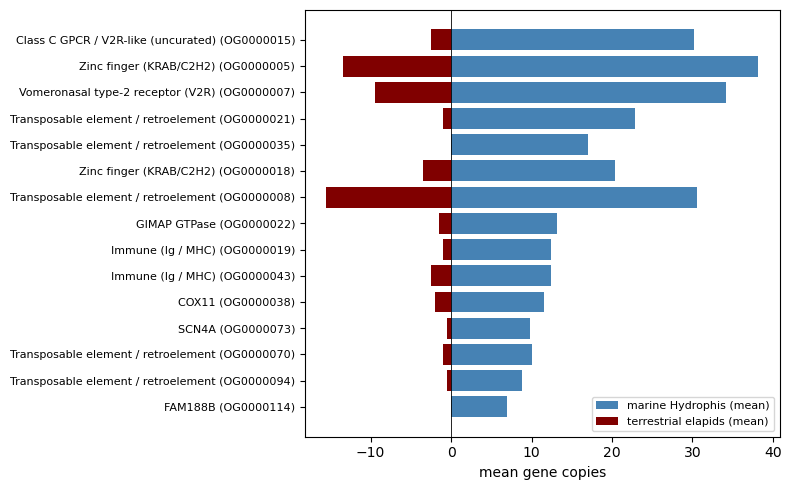

In [61]:
fig,ax=plt.subplots(figsize=(8,5))
h=cand.head(15)[::-1]
ax.barh(range(len(h)),h["marine_mean"],color="steelblue",label="marine Hydrophis (mean)")
ax.barh(range(len(h)),-h["terr_elapid_mean"],color="maroon",label="terrestrial elapids (mean)")
ax.set_yticks(range(len(h))); ax.set_yticklabels([f"{fn(i).split(':')[0]} ({i})" for i in h.index],fontsize=8)
ax.axvline(0,color="k",lw=.6); ax.set(xlabel="mean gene copies")
ax.legend(fontsize=8); plt.tight_layout(); plt.savefig("figures/nb3_seasnake_expanded.png",dpi=130); plt.show()

##  Annotated tree of rapid-family counts
Expansions (▲) and contractions (▼) mapped onto the dated phylogeny.

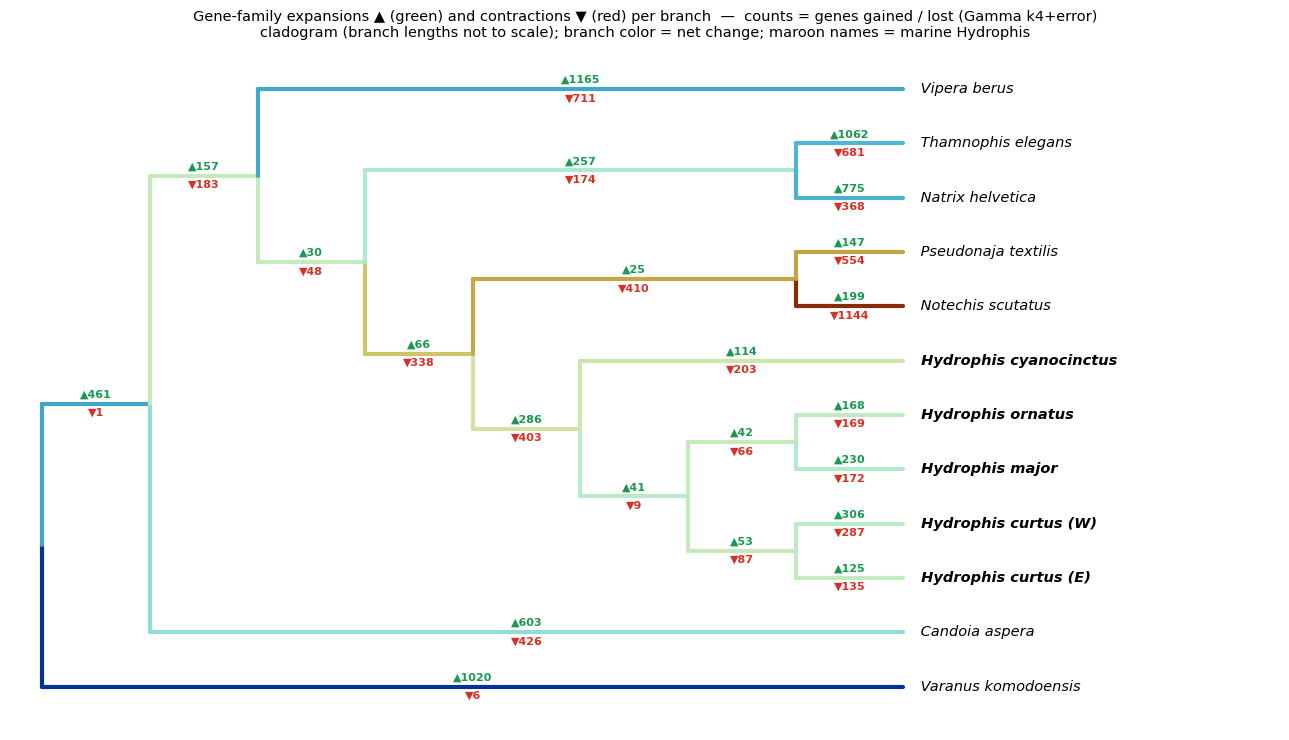

In [85]:
sp_t = dendropy.Tree.get(path="trees/species_tree_ultrametric_multical.nwk", schema="newick", rooting="force-rooted")

# CLADOGRAM layout (branch lengths NOT to scale) so every branch has room for its counts,
    # incl. the very recent (~2 My) Hydrophis radiation that a time-scaled tree crushes together.
h = {}
for nd in sp_t.postorder_node_iter():
    h[nd] = 0 if nd.is_leaf() else 1 + max(h[c] for c in nd.child_nodes())
H = h[sp_t.seed_node]
def xpos(nd): return H - h[nd]                    # root=0 (left) -> tips aligned at x=H (right)
leaves = list(sp_t.leaf_node_iter())
for i,l in enumerate(leaves): l.y = i*1.0
for nd in sp_t.postorder_node_iter():
    if not nd.is_leaf(): nd.y = float(np.mean([c.y for c in nd.child_nodes()]))

# clade (tip set) -> (genes_gained, genes_lost, rapid_families)
tipset_stats = {}
for col,row in summ.iterrows():
    ts = frozenset([re.match(r"([A-Za-z]+)", col).group(1)]) if row["kind"]=="tip" else node_tips.get(int(row["id"]), frozenset())
    tipset_stats[ts] = (int(row["genes_gained"]), int(row["genes_lost"]), int(row["rapid_families"]))

def branch_net(nd):
    ts = frozenset(l.taxon.label for l in nd.leaf_iter())
    st = tipset_stats.get(ts)
    if not st:
        return 0.0
    gained, lost, _ = st
    return float(gained - lost)

branch_d = [branch_net(nd) for nd in sp_t.preorder_node_iter() if nd.parent_node is not None]
lim = max(abs(min(branch_d)), abs(max(branch_d))) or 1.0
norm = TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim)
cmap = cm.roma

marine = {"hcy","hcure","hcurw","horn","hmaj"}
fig, ax = plt.subplots(figsize=(13, 7.5))
for nd in sp_t.preorder_node_iter():
    p = nd.parent_node
    if p is None: continue
    x0, x1 = xpos(p), xpos(nd)
    ts = frozenset(l.taxon.label for l in nd.leaf_iter())
    d_raw = branch_net(nd)
    col = cmap(norm(d_raw))
    lw = 3.0

    ax.plot([x0, x1], [nd.y, nd.y], color=col, lw=lw, zorder=2, solid_capstyle="round")
    ax.plot([x0, x0], [p.y, nd.y], color=col, lw=lw, zorder=2, solid_capstyle="round")

    st = tipset_stats.get(ts)
    if st:
        g, ll, _ = st; xm = (x0 + x1) / 2
        ax.annotate("▲"+str(g), (xm, nd.y), xytext=(0, 3),  textcoords="offset points",
                    ha="center", va="bottom", color="#1a9850", fontsize=8, fontweight="bold", zorder=5)
        ax.annotate("▼"+str(ll), (xm, nd.y), xytext=(0, -3), textcoords="offset points",
                    ha="center", va="top",    color="#d73027", fontsize=8, fontweight="bold", zorder=5)

for l in leaves:
    ax.text(H + 0.12, l.y, " " + smap.get(l.taxon.label, l.taxon.label), va="center", fontsize=10.5,
            style="italic", color="black" if l.taxon.label in marine else "#000",
            fontweight="bold" if l.taxon.label in marine else "normal")
       


ax.set_xlim(-0.3, H + 3.5); ax.set_ylim(-0.8, len(leaves)-0.2)
ax.set_xticks([]); ax.set_yticks([])
for s in ("top","right","left","bottom"): ax.spines[s].set_visible(False)
ax.set_title("Gene-family expansions ▲ (green) and contractions ▼ (red) per branch  —  "
             "counts = genes gained / lost (Gamma k4+error)" + chr(10) +
             "cladogram (branch lengths not to scale); branch color = net change; maroon names = marine Hydrophis", fontsize=10.5)
plt.tight_layout()
# plt.savefig("figures/nb3_tree.png", dpi=140, bbox_inches="tight")
plt.show()

### V2R total-copy expansion/contraction (includes the giant arrays)

- CAFE's birth–death model can't handle the ≥100-copy V2R arrays (`runs/large` (filtered >large gene families) -> returns a non-finite likelihood), 
    - ==> the per-branch V2R tree above omits them 
- instead : map **total V2R copy number per species** 
    — summed over *all* 88 curated/outgroup V2R orthogroups, inc the giant tandem arrays (e.g. OG0000000) 
    - reconstruct ancestral totals by **squared-change parsimony** (branch lengths ignored). 
        - Per-branch Δ = reconstructed child − parent total (▲ net V2R gain, ▼ net loss). 
    - Tip labels show each species' total V2R count.

sea-snake ancestor: 405

 reconstructed V2R totals -> root: 276


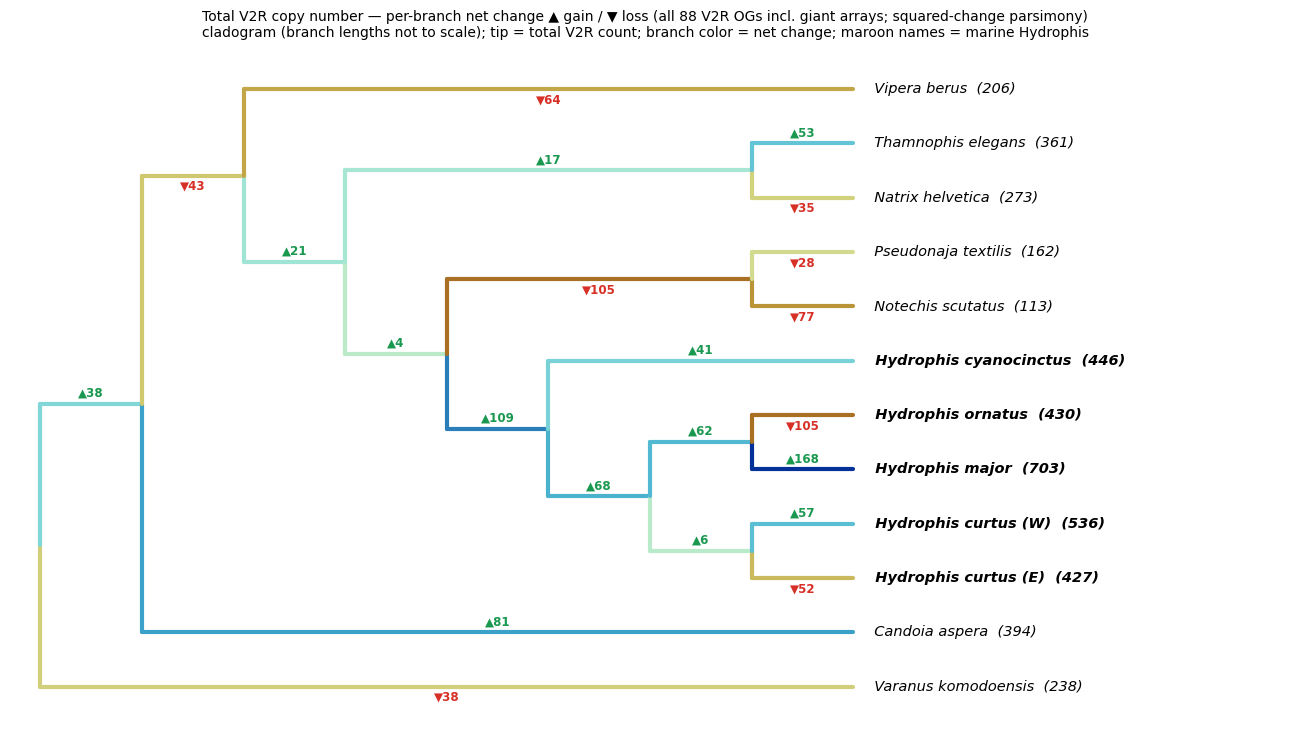

In [84]:
# total V2R copy number per species -> ancestral reconstruction -> per-branch net change
v2r_ogs = set(ann.index[ann.consensus_product == "Vomeronasal type-2 receptor (V2R)"])
gc_all = pd.read_csv("/hpcfs/users/a1864358/sanders_lab/phylogenomics/orthofinder/orthofinder_prot/primary_transcripts_lifted/OrthoFinder/Results_lifted/Orthogroups/Orthogroups.GeneCount.tsv", sep="\t").set_index("Orthogroup")
spp = [c for c in gc_all.columns if c != "Total"]
v2r_total = gc_all.loc[gc_all.index.isin(v2r_ogs), spp].sum()          # per-species total V2R (incl. giant arrays)

# squared-change parsimony (Laplacian relaxation): each internal node = mean of its neighbours, leaves fixed
val = {l: float(v2r_total[l.taxon.label]) for l in sp_t.leaf_node_iter()}
internal = [n for n in sp_t.preorder_node_iter() if not n.is_leaf()]
for n in internal: val[n] = float(np.mean(list(v2r_total)))
for _ in range(5000):
    for n in internal:
        nb_ = list(n.child_nodes()) + ([n.parent_node] if n.parent_node else [])
        val[n] = float(np.mean([val[x] for x in nb_]))
    
# est sea snake ancestor count 
ssanc = round(val[sp_t.mrca(taxon_labels = list(marine))])
print(f"sea-snake ancestor: {ssanc}")
print(f"\n reconstructed V2R totals -> root: {round(val[sp_t.seed_node])}")


branch_d = []
for nd in sp_t.preorder_node_iter():
    p = nd.parent_node
    if p is not None:
        branch_d.append(val[nd] - val[p])
lim = max(abs(min(branch_d)), abs(max(branch_d))) or 1.0
norm = TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim)
cmap = cm.roma

fig, ax = plt.subplots(figsize=(13, 7.5))
for nd in sp_t.preorder_node_iter():
    p = nd.parent_node
    if p is None: continue
    x0, x1 = xpos(p), xpos(nd)
    d_raw = val[nd] - val[p]
    col = cmap(norm(d_raw))
    lw = 3.0
    ax.plot([x0, x1], [nd.y, nd.y], color=col, lw=lw, zorder=2, solid_capstyle="round")
    ax.plot([x0, x0], [p.y, nd.y], color=col, lw=lw, zorder=2, solid_capstyle="round")
    d = round(d_raw); xm = (x0 + x1) / 2
    if d > 0:  ax.annotate("▲"+str(d),  (xm, nd.y), xytext=(0,3),  textcoords="offset points",
                           ha="center", va="bottom", color="#1a9850", fontsize=8.5, fontweight="bold", zorder=5)
    elif d < 0: ax.annotate("▼"+str(-d), (xm, nd.y), xytext=(0,-3), textcoords="offset points",
                           ha="center", va="top",    color="#d73027", fontsize=8.5, fontweight="bold", zorder=5)
for l in leaves:
    ax.text(H + 0.12, l.y, f"  {smap.get(l.taxon.label, l.taxon.label)}  ({int(v2r_total[l.taxon.label])})",
            va="center", fontsize=10.5, style="italic",
            color="black" if l.taxon.label in marine else "#000",
            fontweight="bold" if l.taxon.label in marine else "normal")


ax.set_xlim(-0.3, H + 4.2); ax.set_ylim(-0.8, len(leaves)-0.2)
ax.set_xticks([]); ax.set_yticks([])
for s in ("top","right","left","bottom"): ax.spines[s].set_visible(False)
ax.set_title("Total V2R copy number — per-branch net change ▲ gain / ▼ loss "
             "(all 88 V2R OGs incl. giant arrays; squared-change parsimony)" + chr(10) +
             "cladogram (branch lengths not to scale); tip = total V2R count; branch color = net change; maroon names = marine Hydrophis", fontsize=10)
plt.tight_layout(); plt.savefig("figures/nb3_tree_v2r_total.png", dpi=140, bbox_inches="tight"); plt.show()

### OR total-copy expansion/contraction

sea-snake ancestor: 154

 reconstructed OR totals -> root: 387


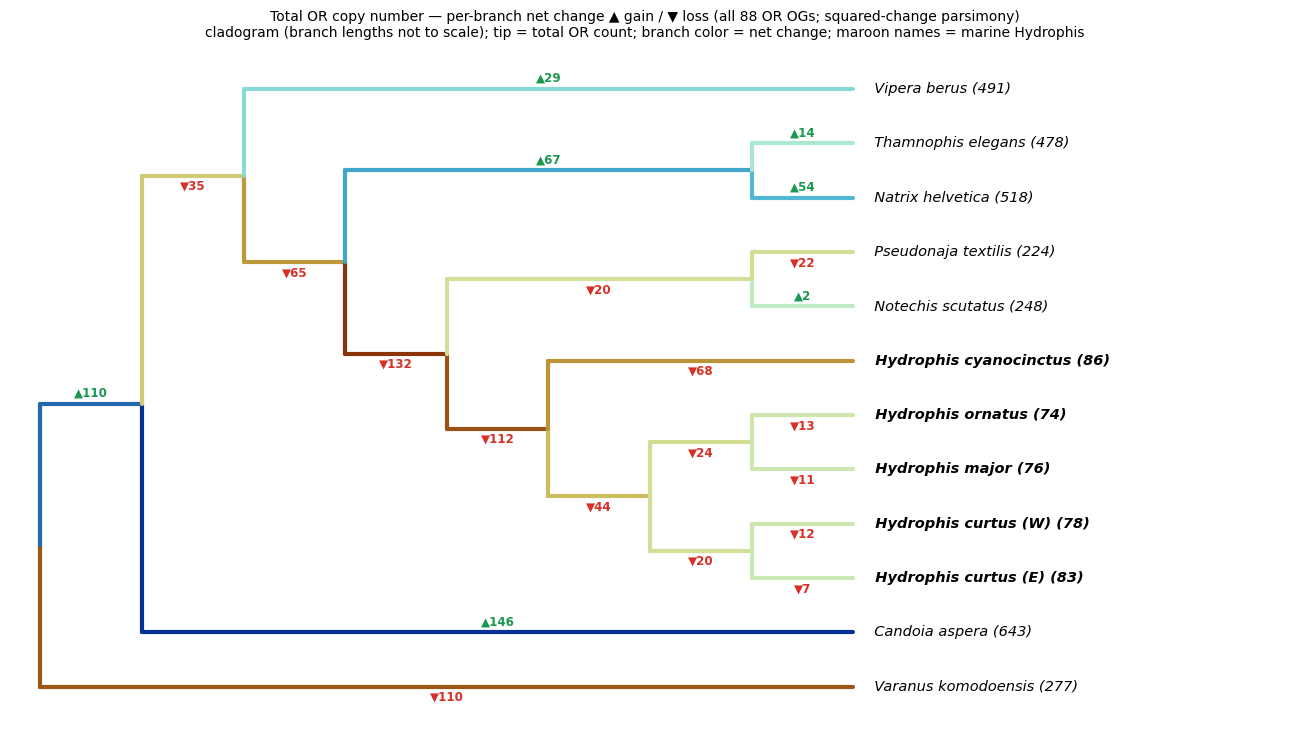

In [83]:
or_ogs = set(ann.index[ann.consensus_product == "Olfactory receptor (OR)"])
gc_all = pd.read_csv("/hpcfs/users/a1864358/sanders_lab/phylogenomics/orthofinder/orthofinder_prot/primary_transcripts_lifted/OrthoFinder/Results_lifted/Orthogroups/Orthogroups.GeneCount.tsv", sep="\t").set_index("Orthogroup")
spp = [c for c in gc_all.columns if c != "Total"]
or_total = gc_all.loc[gc_all.index.isin(or_ogs), spp].sum()          # per-species total OR

# squared-change parsimony (Laplacian relaxation): each internal node = mean of its neighbours, leaves fixed
val = {l: float(or_total[l.taxon.label]) for l in sp_t.leaf_node_iter()}
internal = [n for n in sp_t.preorder_node_iter() if not n.is_leaf()]
for n in internal: val[n] = float(np.mean(list(or_total)))
for _ in range(5000):
    for n in internal:
        nb_ = list(n.child_nodes()) + ([n.parent_node] if n.parent_node else [])
        val[n] = float(np.mean([val[x] for x in nb_]))
    
# est sea snake ancestor count 
ssanc = round(val[sp_t.mrca(taxon_labels = list(marine))])
print(f"sea-snake ancestor: {ssanc}")
print(f"\n reconstructed OR totals -> root: {round(val[sp_t.seed_node])}")


branch_d = []
for nd in sp_t.preorder_node_iter():
    p = nd.parent_node
    if p is not None:
        branch_d.append(val[nd] - val[p])
lim = max(abs(min(branch_d)), abs(max(branch_d))) or 1.0
norm = TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim)
cmap = cm.roma

fig, ax = plt.subplots(figsize=(13, 7.5))
for nd in sp_t.preorder_node_iter():
    p = nd.parent_node
    if p is None: continue
    x0, x1 = xpos(p), xpos(nd)
    d_raw = val[nd] - val[p]
    col = cmap(norm(d_raw))
    lw = 3.0
    ax.plot([x0, x1], [nd.y, nd.y], color=col, lw=lw, zorder=2, solid_capstyle="round")
    ax.plot([x0, x0], [p.y, nd.y], color=col, lw=lw, zorder=2, solid_capstyle="round")
    d = round(d_raw); xm = (x0 + x1) / 2
    if d > 0:  ax.annotate("▲"+str(d),  (xm, nd.y), xytext=(0,3),  textcoords="offset points",
                           ha="center", va="bottom", color="#1a9850", fontsize=8.5, fontweight="bold", zorder=5)
    elif d < 0: ax.annotate("▼"+str(-d), (xm, nd.y), xytext=(0,-3), textcoords="offset points",
                           ha="center", va="top",    color="#d73027", fontsize=8.5, fontweight="bold", zorder=5)
for l in leaves:
    ax.text(H + 0.12, l.y, f"  {smap.get(l.taxon.label, l.taxon.label)} ({int(or_total[l.taxon.label])})",
            va="center", fontsize=10.5, style="italic",
            color="black" if l.taxon.label in marine else "#000",
            fontweight="bold" if l.taxon.label in marine else "normal")


ax.set_xlim(-0.3, H + 4.2); ax.set_ylim(-0.8, len(leaves)-0.2)
ax.set_xticks([]); ax.set_yticks([])
for s in ("top","right","left","bottom"): ax.spines[s].set_visible(False)
ax.set_title("Total OR copy number — per-branch net change ▲ gain / ▼ loss "
             "(all 88 OR OGs; squared-change parsimony)" + chr(10) +
             "cladogram (branch lengths not to scale); tip = total OR count; branch color = net change; maroon names = marine Hydrophis", fontsize=10)

plt.tight_layout(); plt.savefig("figures/nb3_tree_or_total.png", dpi=140, bbox_inches="tight"); plt.show()

#### Summary

In [65]:

summary_data = {
    "Best model": [mc.sort_values("AIC").iloc[0]["name"]],
    "Total families": [int(len(fr))],
    "Rapidly evolving": [int(len(sig))],
    "Marine expanded": [int(len(exp))],
    "Marine contracted": [int(len(con))]
}

summary_df = pd.DataFrame(summary_data)
print("Summary statistics:\n")
display(summary_df)  # If running in Jupyter, this prints as a table

print("\nTop branches with most rapid families:")
display(summ.sort_values("rapid_families", ascending=False).head(5)[["clade", "rapid_families", "genes_gained", "genes_lost"]])

print("\nTop 10 marine expanded families:")
top_marine_families = [(i, fn(i)) for i in cand.head(10).index]
df_top_marine = pd.DataFrame(top_marine_families, columns=["OG", "Description"])
display(df_top_marine)

Summary statistics:



,Best model,Total families,Rapidly evolving,Marine expanded,Marine contracted
0,Gamma k4+error,16341,1691,105,203



Top branches with most rapid families:


,clade,rapid_families,genes_gained,genes_lost
col,,,,
tele<11>,Thamnophis elegans,605,1062,681
nhel<10>,Natrix helvetica,486,775,368
nscut<8>,Notechis scutatus,478,199,1144
vberus<12>,Vipera berus,347,1165,711
hcurw<4>,Hydrophis curtus (W),341,306,287



Top 10 marine expanded families:


,OG,Description
0,OG0000015,Class C GPCR / V2R-like (uncurated)
1,OG0000005,Zinc finger (KRAB/C2H2)
2,OG0000007,Vomeronasal type-2 receptor (V2R)
3,OG0000021,Transposable element / retroelement
4,OG0000035,Transposable element / retroelement
5,OG0000018,Zinc finger (KRAB/C2H2)
6,OG0000008,Transposable element / retroelement
7,OG0000022,GIMAP GTPase
8,OG0000019,Immune (Ig / MHC)
9,OG0000043,Immune (Ig / MHC)


- OG0000015 (the #1 marine expander) is now "V2R-like (uncurated)" — eggNOG calls it Vmn2r, has Hydrophis genes, but your curation did not flag them as intact V2R. Likely a V2R pseudogene/fragment expansion, not intact V2R.
- OG0000021 / 0035 / 0008 — were "V2R" under raw Hydrophis text, now "Transposable element" (eggNOG: RNase-H/reverse-transcriptase). Raw BLAST had mislabeled TE-rich OGs as V2R; now correct.

In [66]:
# locate OG15 on genome 